## Fine-grain depth resolution (expanded layer3/layer4)

We plot probes over a mixed depth axis:
- **Coarse**: conv1, layer1, layer2
- **Fine**: each bottleneck block in layer3 and layer4 (e.g., layer3.0 … layer3.5; layer4.0 … layer4.2)
- **End**: avgpool

This gives higher resolution where semantic structure typically forms (late mid → deep layers), without making the x-axis too long early.


In [2]:
# CELL — Fine-grain layer axis + parsing

import re
import numpy as np
import pandas as pd

# Mixed axis: coarse up to layer2, then fine blocks for layer3 and layer4, then avgpool
LAYERS_FINE = (
    ["conv1", "layer1", "layer2"]
    + [f"layer3.{i}" for i in range(6)]   # ResNet-50: layer3 has 6 bottleneck blocks
    + [f"layer4.{i}" for i in range(3)]   # ResNet-50: layer4 has 3 bottleneck blocks
    + ["avgpool"]
)

layer_to_idx_fine = {l: i for i, l in enumerate(LAYERS_FINE)}

def normalize_layer_name(layer: str) -> str | None:
    """
    Map various possible layer naming conventions into our canonical names in LAYERS_FINE.

    Accepts (examples):
      - "conv1", "layer1", "layer2", "layer3", "layer4", "avgpool"
      - "layer3.0", "layer3.1", ..., "layer4.2"
      - "layer3_0", "layer4_2"
      - "layer3/block0", "layer4/block2"  (if you logged like that)
      - "layer3[0]" etc.

    Returns canonical name in LAYERS_FINE or None if unknown.
    """
    if layer is None or (isinstance(layer, float) and np.isnan(layer)):
        return None

    s = str(layer).strip()

    # direct hit
    if s in layer_to_idx_fine:
        return s

    # coarse names: keep as-is if we support them
    if s in ["conv1", "layer1", "layer2", "avgpool"]:
        return s

    # If someone logged "layer3" or "layer4" without block index:
    # we cannot place it precisely; we’ll treat it as the *coarse* version
    # by mapping to the first block (layer3.0 / layer4.0) ONLY if you want.
    # Safer default: return None so you notice you don't have fine-grain data.
    if s == "layer3" or s == "layer4":
        return None

    # Patterns: layer3.0 / layer3_0 / layer3[0] / layer3/block0 etc.
    m = re.search(r"(layer[34])[^0-9]*([0-9]+)", s)
    if m:
        base = m.group(1)      # "layer3" or "layer4"
        idx  = int(m.group(2)) # block index
        canon = f"{base}.{idx}"
        if canon in layer_to_idx_fine:
            return canon

    return None

print("Fine-grain axis length:", len(LAYERS_FINE))
print("Axis:", LAYERS_FINE)


Fine-grain axis length: 13
Axis: ['conv1', 'layer1', 'layer2', 'layer3.0', 'layer3.1', 'layer3.2', 'layer3.3', 'layer3.4', 'layer3.5', 'layer4.0', 'layer4.1', 'layer4.2', 'avgpool']


In [11]:
# CELL — Load JSON results (baseline + cbm) and normalize to fine-grain layers

import json
from pathlib import Path

# ---- Paths (baseline + cbm) ----
BASELINE_JSON = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/results/probes/resnet50_cub_probes_attributes_fine.json")
CBM_JSON      = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_cbm_probes_attributes.json")

assert BASELINE_JSON.exists(), f"Missing {BASELINE_JSON}"
assert CBM_JSON.exists(), f"Missing {CBM_JSON}"

def load_probe_json(path: Path, model_name: str) -> pd.DataFrame:
    with open(path, "r") as f:
        data = json.load(f)  # list[dict]
    df = pd.DataFrame(data)
    df["model"] = model_name
    return df

df_all = pd.concat(
    [load_probe_json(BASELINE_JSON, "baseline"),
     load_probe_json(CBM_JSON, "cbm")],
    ignore_index=True
)

needed_cols = {"layer", "target_type", "target_name", "best_val_acc", "group", "model"}
missing = needed_cols - set(df_all.columns)
assert not missing, f"Missing required columns in JSON: {missing}"

# Normalize layer names → canonical fine-grain names
df_all["layer_raw"] = df_all["layer"]
df_all["layer"] = df_all["layer"].apply(normalize_layer_name)

# Print what we actually have
raw_layers = sorted(df_all["layer_raw"].dropna().astype(str).unique().tolist())
norm_layers = sorted(df_all["layer"].dropna().astype(str).unique().tolist())

print("Loaded df_all:", df_all.shape)
print("Models:", df_all["model"].unique())
print("Target types:", df_all["target_type"].unique())

print("\nUnique RAW layers in JSON (first 40):", raw_layers[:40], ("..." if len(raw_layers) > 40 else ""))
print("Unique NORMALIZED layers kept (all):", norm_layers)

# Keep only layers that landed on our axis
df_all = df_all[df_all["layer"].isin(LAYERS_FINE)].copy()
df_all["layer_idx"] = df_all["layer"].map(layer_to_idx_fine)

print("\nAfter filtering to LAYERS_FINE:", df_all.shape)
print("Remaining normalized layers:", sorted(df_all["layer"].unique().tolist()))
df_all.head()


AssertionError: Missing /scratch/network/cr7998/cv_emergence_project/results/probes/results/probes/resnet50_cub_probes_attributes_fine.json

In [5]:
# CELL — Curve helper for fine-grain axis

def get_curve(df: pd.DataFrame, target_type: str, target_name: str, model: str) -> pd.Series:
    sub = df[(df["model"] == model) &
             (df["target_type"] == target_type) &
             (df["target_name"] == target_name)].copy()
    if sub.empty:
        return pd.Series(index=LAYERS_FINE, dtype=float)

    # if duplicates exist, take max best_val_acc per layer
    sub = sub.groupby("layer", as_index=False)["best_val_acc"].max()
    sub["layer_idx"] = sub["layer"].map(layer_to_idx_fine)
    sub = sub.sort_values("layer_idx")

    curve = pd.Series(sub["best_val_acc"].values, index=sub["layer"].values)
    curve = curve.reindex(LAYERS_FINE)  # fill missing with NaN
    return curve


In [6]:
# CELL — Sharp-rise emergence on fine-grain axis

def sharp_rise_layer(curve: pd.Series) -> str | None:
    vals = curve.values.astype(float)
    if np.all(np.isnan(vals)):
        return None

    # fill missing so diffs work
    vals_ff = pd.Series(vals).ffill().bfill().values
    diffs = np.diff(vals_ff)
    j = int(np.argmax(diffs))
    return LAYERS_FINE[j + 1]

# Build emerge_df (attributes + species) per model
records = []
targets = df_all[["target_type", "target_name", "group"]].drop_duplicates()

for _, row in targets.iterrows():
    ttype = row["target_type"]
    tname = row["target_name"]
    tgroup = row["group"]

    for model in ["baseline", "cbm"]:
        curve = get_curve(df_all, ttype, tname, model)
        if curve.empty or np.all(np.isnan(curve.values)):
            continue
        max_acc = float(np.nanmax(curve.values))
        em_layer = sharp_rise_layer(curve)
        records.append({
            "model": model,
            "target_type": ttype,
            "target_name": tname,
            "group": tgroup,
            "max_acc": max_acc,
            "emergence_layer": em_layer
        })

emerge_df = pd.DataFrame(records)
emerge_df["layer_idx"] = emerge_df["emergence_layer"].map(layer_to_idx_fine)

print("Total targets measured (rows = target x model):", len(emerge_df))
emerge_df.head()


Total targets measured (rows = target x model): 220


,model,target_type,target_name,group,max_acc,emergence_layer,layer_idx
0,baseline,subclass,species,species,0.727822,avgpool,12
1,cbm,subclass,species,species,0.620297,avgpool,12
2,baseline,attribute,has_bill_shape::dagger,has_bill_shape,0.878668,avgpool,12
3,cbm,attribute,has_bill_shape::dagger,has_bill_shape,0.884708,layer1,1
4,baseline,attribute,has_bill_shape::all-purpose,has_bill_shape,0.721263,avgpool,12


In [7]:
# CELL — Plot curve on fine-grain axis (readable ticks)

import matplotlib.pyplot as plt

def plot_curve_fine(curve_baseline: pd.Series, curve_cbm: pd.Series, title: str):
    x = np.arange(len(LAYERS_FINE))

    plt.figure(figsize=(12, 4))
    plt.plot(x, curve_baseline.values, marker="o", label="baseline")
    plt.plot(x, curve_cbm.values, marker="o", label="cbm")

    plt.xticks(x, LAYERS_FINE, rotation=45, ha="right")
    plt.ylim(0, 1.0)
    plt.xlabel("Layer (coarse ≤ layer2, fine blocks for layer3/layer4)")
    plt.ylabel("Probe accuracy (best_val)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


Total attributes compared: 109
Changed emergence (any): 12
Changed by ≥2 ticks: 12

Top shifts later under CBM:


,target_name,group,emergence_layer_base,emergence_layer_cbm,delta_idx,max_acc_base,max_acc_cbm
104,has_crown_color::white,has_crown_color,layer1,avgpool,11,0.913531,0.914049
7,has_wing_color::buff,has_wing_color,layer1,avgpool,11,0.829997,0.834139
14,has_underparts_color::grey,has_underparts_color,layer1,avgpool,11,0.826200,0.832585
25,has_back_color::white,has_back_color,layer1,avgpool,11,0.866241,0.867104
98,has_bill_color::grey,has_bill_color,layer1,avgpool,11,0.731446,0.738523
51,has_eye_color::black,has_eye_color,layer1,avgpool,11,0.851743,0.848464
57,has_forehead_color::white,has_forehead_color,layer1,avgpool,11,0.899724,0.901795
28,has_tail_shape::notched_tail,has_tail_shape,layer2,avgpool,10,0.704177,0.705385
77,has_size::medium_(9_-_16_in),has_size,avgpool,avgpool,0,0.858302,0.856576
76,has_size::small_(5_-_9_in),has_size,avgpool,avgpool,0,0.653952,0.654815



Top shifts earlier under CBM:


,target_name,group,emergence_layer_base,emergence_layer_cbm,delta_idx,max_acc_base,max_acc_cbm
0,has_bill_shape::dagger,has_bill_shape,avgpool,layer1,-11,0.878668,0.884708
64,has_nape_color::brown,has_nape_color,avgpool,layer1,-11,0.845530,0.845012
60,has_under_tail_color::grey,has_under_tail_color,avgpool,layer1,-11,0.791681,0.795133
54,has_forehead_color::brown,has_forehead_color,avgpool,layer1,-11,0.851571,0.851053
4,has_wing_color::grey,has_wing_color,avgpool,avgpool,0,0.728857,0.743183
78,has_size::very_small_(3_-_5_in),has_size,layer1,layer1,0,0.765274,0.769589
77,has_size::medium_(9_-_16_in),has_size,avgpool,avgpool,0,0.858302,0.856576
76,has_size::small_(5_-_9_in),has_size,avgpool,avgpool,0,0.653952,0.654815
75,has_wing_shape::pointed-wings,has_wing_shape,layer1,layer1,0,0.799620,0.799275
74,has_wing_shape::rounded-wings,has_wing_shape,layer1,layer1,0,0.714705,0.714705



Picked attributes to plot:
  has_crown_color::white               layer1 -> avgpool   (Δ=11)
  has_wing_color::buff                 layer1 -> avgpool   (Δ=11)
  has_underparts_color::grey           layer1 -> avgpool   (Δ=11)
  has_back_color::white                layer1 -> avgpool   (Δ=11)
  has_bill_color::grey                 layer1 -> avgpool   (Δ=11)
  has_bill_shape::dagger               avgpool -> layer1   (Δ=-11)
  has_nape_color::brown                avgpool -> layer1   (Δ=-11)
  has_under_tail_color::grey           avgpool -> layer1   (Δ=-11)
  has_forehead_color::brown            avgpool -> layer1   (Δ=-11)
  has_wing_color::grey                 avgpool -> avgpool   (Δ=0)


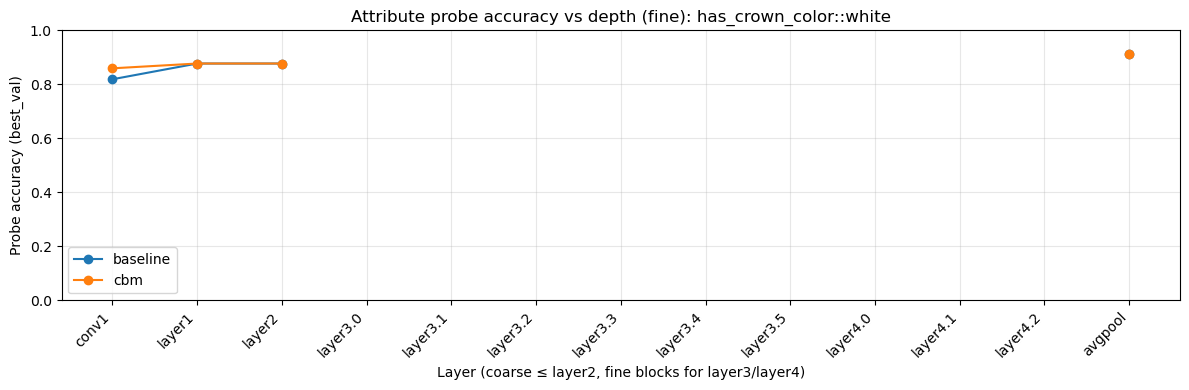

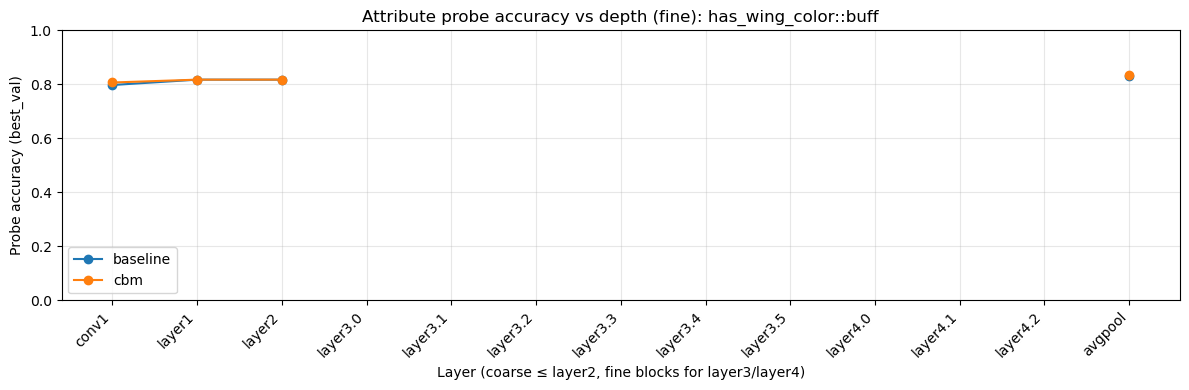

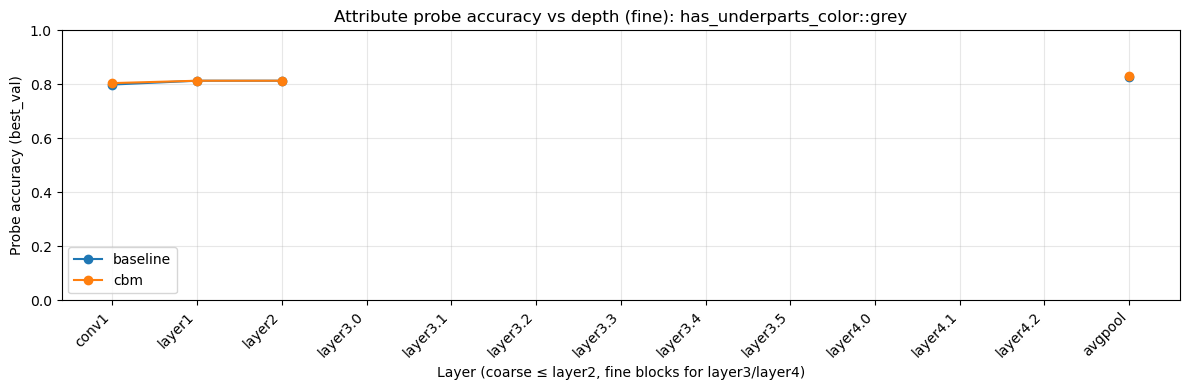

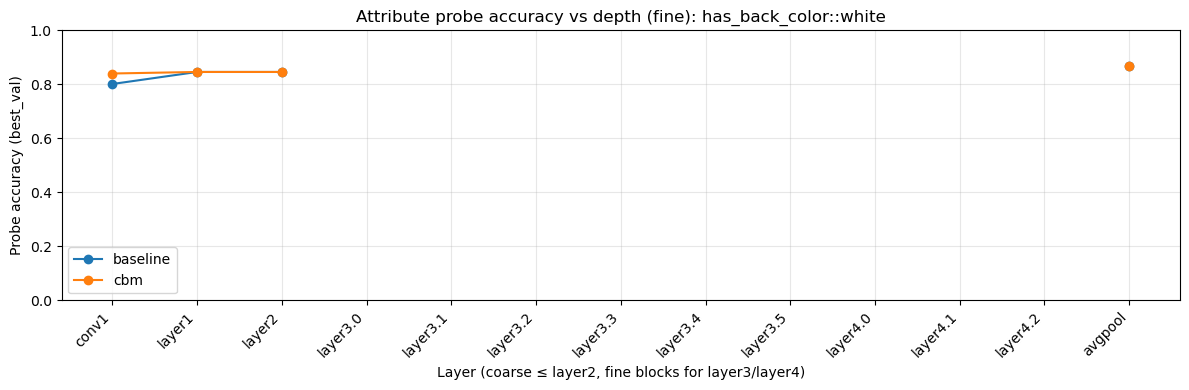

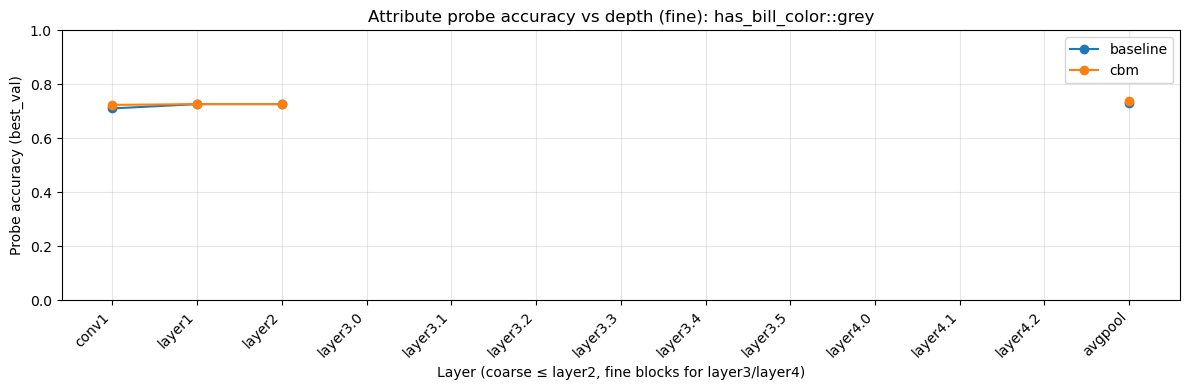

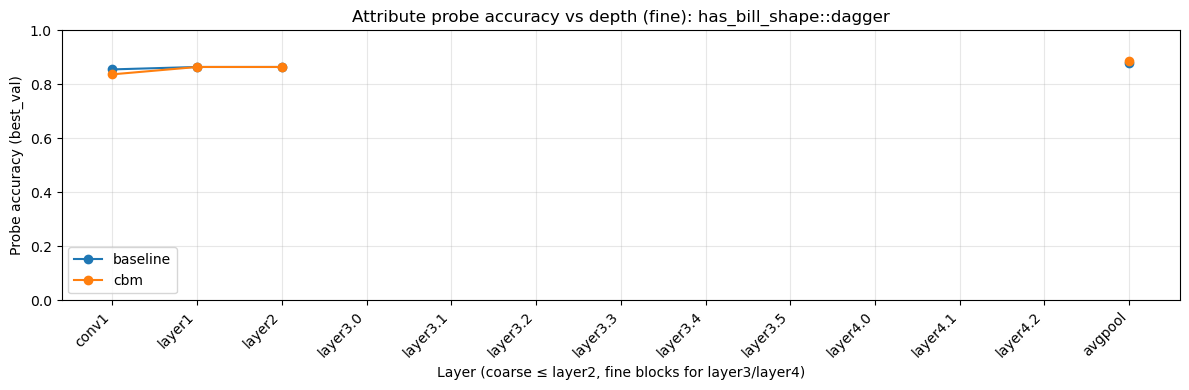

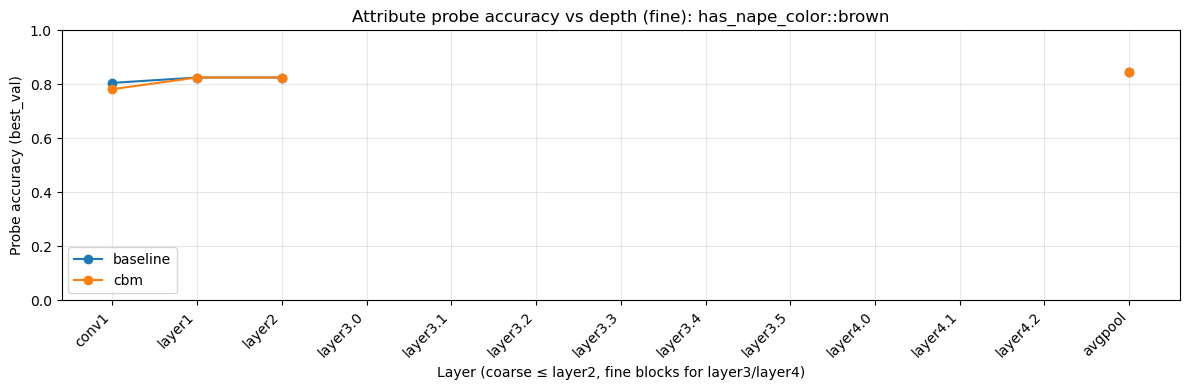

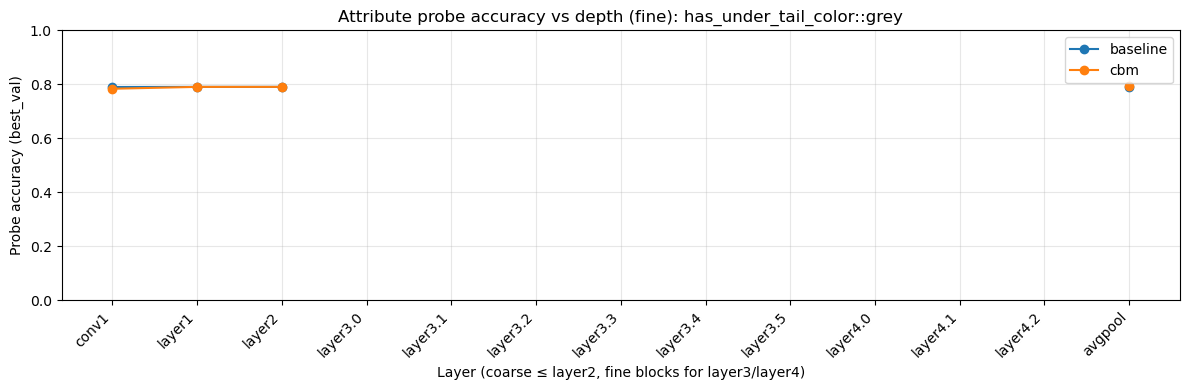

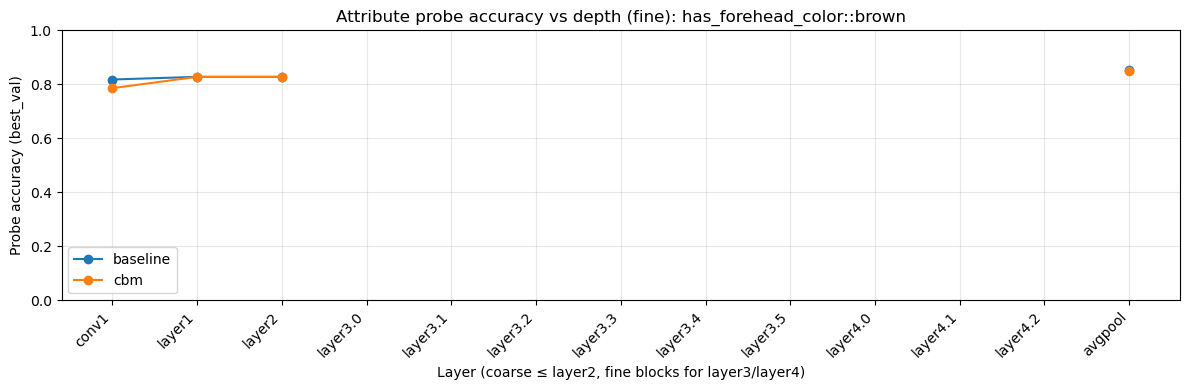

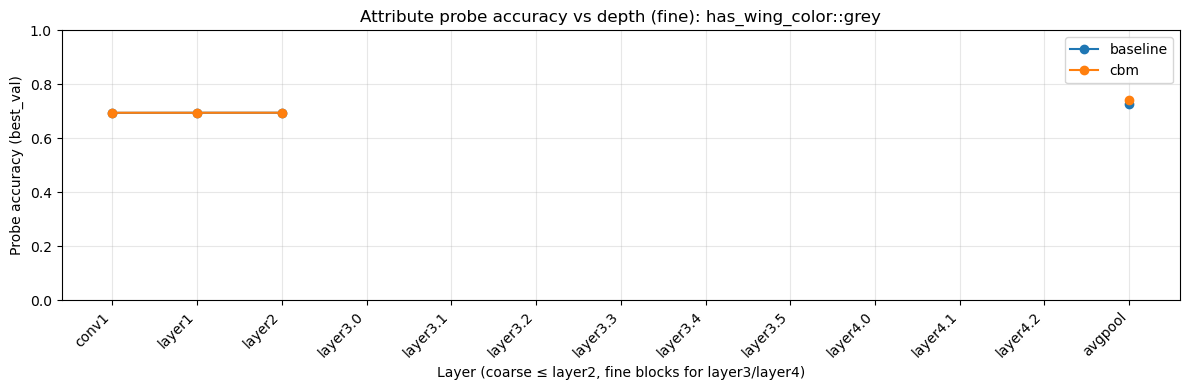

In [8]:
# CELL — Find impactful attributes (big emergence shift) and plot their probe curves

# Split emerge_df by model
base_em = emerge_df[(emerge_df["model"] == "baseline") & (emerge_df["target_type"] == "attribute")].copy()
cbm_em  = emerge_df[(emerge_df["model"] == "cbm")      & (emerge_df["target_type"] == "attribute")].copy()

# Merge baseline vs cbm per attribute
comp = base_em.merge(
    cbm_em,
    on=["target_type", "target_name", "group"],
    suffixes=("_base", "_cbm")
)

comp["delta_idx"] = comp["layer_idx_cbm"] - comp["layer_idx_base"]
comp["abs_delta"] = comp["delta_idx"].abs()

print("Total attributes compared:", len(comp))
print("Changed emergence (any):", int((comp["delta_idx"] != 0).sum()))
print("Changed by ≥2 ticks:", int((comp["abs_delta"] >= 2).sum()))

# Show biggest shifts (later in CBM)
print("\nTop shifts later under CBM:")
display(comp.sort_values("delta_idx", ascending=False)[
    ["target_name", "group", "emergence_layer_base", "emergence_layer_cbm", "delta_idx", "max_acc_base", "max_acc_cbm"]
].head(12))

# Show biggest shifts earlier in CBM
print("\nTop shifts earlier under CBM:")
display(comp.sort_values("delta_idx", ascending=True)[
    ["target_name", "group", "emergence_layer_base", "emergence_layer_cbm", "delta_idx", "max_acc_base", "max_acc_cbm"]
].head(12))

# Pick a small set to plot
TOPK = 5
picked_late   = comp.sort_values("delta_idx", ascending=False).head(TOPK)["target_name"].tolist()
picked_early  = comp.sort_values("delta_idx", ascending=True).head(TOPK)["target_name"].tolist()

picked = []
for a in picked_late + picked_early:
    if a not in picked:
        picked.append(a)

print("\nPicked attributes to plot:")
for a in picked:
    row = comp[comp["target_name"] == a].iloc[0]
    print(f"  {a:35s}  {row['emergence_layer_base']} -> {row['emergence_layer_cbm']}   (Δ={int(row['delta_idx'])})")

# Plot curves
for a in picked:
    c0 = get_curve(df_all, "attribute", a, "baseline")
    c1 = get_curve(df_all, "attribute", a, "cbm")
    plot_curve_fine(c0, c1, f"Attribute probe accuracy vs depth (fine): {a}")


In [10]:
# CELL — Diagnostic: do we actually have fine-grain layers?

have_layer3_blocks = any(l.startswith("layer3.") for l in df_all["layer"].unique())
have_layer4_blocks = any(l.startswith("layer4.") for l in df_all["layer"].unique())

print("Have layer3.* blocks?", have_layer3_blocks)
print("Have layer4.* blocks?", have_layer4_blocks)

if not (have_layer3_blocks or have_layer4_blocks):
    print("\n⚠️ Your loaded probe JSONs do not contain fine-grain layer names.")
    print("That means you cannot 'expand layer3/layer4' just by plotting—")
    print("you need probe outputs computed at block-level features (layer3.0, layer3.1, ...).")
    print("\nNext step: re-run probe extraction saving per-block representations,")
    print("or point BASELINE_JSON / CBM_JSON to the fine-grain probe result files if you already generated them.")


Have layer3.* blocks? False
Have layer4.* blocks? False

⚠️ Your loaded probe JSONs do not contain fine-grain layer names.
That means you cannot 'expand layer3/layer4' just by plotting—
you need probe outputs computed at block-level features (layer3.0, layer3.1, ...).

Next step: re-run probe extraction saving per-block representations,
or point BASELINE_JSON / CBM_JSON to the fine-grain probe result files if you already generated them.
